# DDXPlus Single-Agent Structured Policy Refinement

This successor notebook keeps the same single-agent sequential setup but tightens the policy logic in three places:

- a deterministic diagnosis-state manager that anchors the evolving differential
- shortlist scoring that explicitly separates the current top competing diagnoses
- stop/request and drift-guard logic that reduces late-turn diagnostic collapse

It also adds offline replay diagnostics against the earlier live structured-policy run so that policy changes can be tested cheaply before spending more API budget.

In [22]:
# Optional secure env bootstrap for live API runs.
# This cell is execution-safe by default. Uncomment the getpass block only for interactive live runs.

import os

os.environ.setdefault("LLM_BASE_URL", "https://api.openai.com/v1")
os.environ.setdefault("LLM_MODEL", "gpt-4.1-mini")

from getpass import getpass
if not os.environ.get("LLM_API_KEY"):
    os.environ["LLM_API_KEY"] = getpass("Enter LLM_API_KEY: ")


In [23]:
from __future__ import annotations

import ast
import json
import math
import os
import random
import re
import subprocess
import sys
import time
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 20)

ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent]
        if (candidate / "scripts" / "download_ddxplus.py").exists()
    ),
    Path.cwd(),
)
DATASET_ENV_VAR = "DDXPLUS_DATASET_DIR"
DEFAULT_DATASET_DIR = ROOT / "dataset"
LEGACY_DATASET_DIR = ROOT / ".data" / "ddxplus" / "22687585"
DATASET_DIR = (
    Path(os.environ[DATASET_ENV_VAR]).expanduser()
    if os.environ.get(DATASET_ENV_VAR)
    else DEFAULT_DATASET_DIR
    if DEFAULT_DATASET_DIR.exists()
    else LEGACY_DATASET_DIR
    if LEGACY_DATASET_DIR.exists()
    else DEFAULT_DATASET_DIR
)
AUTO_DOWNLOAD_IF_MISSING = True

RUN_LIVE_API = True
ALLOW_DRY_RUN_BENCHMARK = False
RUN_REPLAY_DIAGNOSTICS = True
RESUME_IF_AVAILABLE = True

REQUEST_BUDGETS = [1, 3, 5, 8]
SEQUENTIAL_SAMPLE_PER_CLASS = 1
SEQUENTIAL_MAX_CASES = 10
RANDOM_SEED = 2919
SPLIT_NAME = "test"
TEMPERATURE = 0.1

SHORTLIST_SIZE = 10
SHORTLIST_STATS_SOURCE = "validate"
SHORTLIST_STATS_MAX_ROWS = 30000
USE_ONE_SHOT_PRIOR = True
ONE_SHOT_PRIOR_TOP_K = 5
PRIOR_BLEND_WEIGHT = 0.55
STATE_TOP_K = 5
STATE_SOFTMAX_TEMPERATURE = 0.33
STOP_CONFIDENCE_THRESHOLD = 0.60
LOW_VALUE_SHORTLIST_THRESHOLD = 0.12
GENERIC_RATE_PENALTY_THRESHOLD = 0.50

DRIFT_GUARD_TOP_K = 4
DRIFT_GUARD_MARGIN_THRESHOLD = 0.08
DRIFT_GUARD_CONFIDENCE_THRESHOLD = 0.72
FORCE_REQUEST_MARGIN_THRESHOLD = 0.07
FORCE_REQUEST_SCORE_THRESHOLD = 0.14
FORCE_STOP_MAX_SHORTLIST_SCORE = 0.10

REPLAY_SOURCE_RUN_NAME = "single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1"
RUN_VERSION = "anchor_guard_v1"

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "https://api.openai.com/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-5.4-mini")
USE_JSON_MODE = False

INPUT_COST_PER_1K_TOKENS = None
OUTPUT_COST_PER_1K_TOKENS = None

run_prefix = "live" if RUN_LIVE_API else "dryrun"
RUN_NAME = (
    f"single_agent_refined_{run_prefix}_{SPLIT_NAME}_"
    f"{SEQUENTIAL_SAMPLE_PER_CLASS}perclass_{len(REQUEST_BUDGETS)}budgets_{RUN_VERSION}"
)
ARTIFACT_ROOT = ROOT / "artifacts" / "sequential_single_agent_refined" / RUN_NAME
CACHE_DIR = ARTIFACT_ROOT / "cache"
FIGURE_DIR = ARTIFACT_ROOT / "figures"
for directory in [ARTIFACT_ROOT, CACHE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root      :", ROOT)
print("Dataset dir       :", DATASET_DIR)
print("Run live API      :", RUN_LIVE_API)
print("Replay diagnostics:", RUN_REPLAY_DIAGNOSTICS, REPLAY_SOURCE_RUN_NAME)
print("Request budgets   :", REQUEST_BUDGETS)
print("Sample per class  :", SEQUENTIAL_SAMPLE_PER_CLASS)
print("Max benchmark rows:", SEQUENTIAL_MAX_CASES)
print("Artifact root     :", ARTIFACT_ROOT)


Project root      : /Users/bilalawan/claw/assignments/baseline_model
Dataset dir       : /Users/bilalawan/claw/assignments/baseline_model/.data/ddxplus/22687585
Run live API      : True
Replay diagnostics: True single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1
Request budgets   : [1, 3, 5, 8]
Sample per class  : 1
Max benchmark rows: 10
Artifact root     : /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_refined/single_agent_refined_live_test_1perclass_4budgets_anchor_guard_v1



## Dataset And Artifact Helpers

The improved notebook keeps the same DDXPlus file-validation and split-loading conventions as the rest of the project so that:

- `case_id` remains stable
- one-shot predictions can be merged cleanly as priors
- sequential budget sweeps can be compared later without ad-hoc reformatting


In [24]:

REQUIRED_FILES = [
    "release_evidences.json",
    "release_conditions.json",
    "release_train_patients.zip",
    "release_validate_patients.zip",
    "release_test_patients.zip",
]

SPLIT_TO_FILENAME = {
    "train": "release_train_patients.zip",
    "validate": "release_validate_patients.zip",
    "test": "release_test_patients.zip",
}


def ensure_dataset_present(dataset_dir: Path, auto_download: bool = True) -> dict[str, Path]:
    dataset_dir.mkdir(parents=True, exist_ok=True)
    paths = {name: dataset_dir / name for name in REQUIRED_FILES}
    missing = [name for name, path in paths.items() if not path.exists()]
    if missing and auto_download:
        command = [sys.executable, str(ROOT / "scripts" / "download_ddxplus.py"), "--output-dir", str(dataset_dir)]
        subprocess.run(command, check=True)
        missing = [name for name, path in paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing DDXPlus files: {missing}")
    return paths


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_patient_split(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        members = [name for name in archive.namelist() if not name.endswith("/")]
        file_name = next((name for name in members if name.endswith(".csv")), None)
        if file_name is None:
            if not members:
                raise ValueError(f"Archive is empty: {zip_path}")
            file_name = members[0]
        with archive.open(file_name) as handle:
            return pd.read_csv(handle)


def attach_split_metadata(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    enriched = frame.copy()
    enriched["split"] = split_name
    enriched["source_row_index"] = np.arange(len(enriched), dtype=int)
    enriched["case_id"] = enriched["source_row_index"].map(lambda idx: f"{split_name}:{idx}")
    return enriched


def sample_fixed_cases_per_pathology(frame: pd.DataFrame, label_col: str, per_class: int, seed: int) -> pd.DataFrame:
    sampled_parts = []
    for pathology, group in frame.groupby(label_col, sort=True):
        take_n = min(per_class, len(group))
        sampled_parts.append(group.sample(n=take_n, random_state=seed))
    sampled = pd.concat(sampled_parts, ignore_index=False)
    sampled = sampled.sort_values([label_col, "source_row_index"]).reset_index(drop=True)
    return sampled


def append_jsonl(path: Path, payload: dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=True) + "\n")


def upsert_prediction_row(path: Path, row: dict[str, Any]) -> None:
    frame = pd.DataFrame([row])
    if path.exists():
        existing = pd.read_csv(path)
        existing = existing[existing["case_id"] != row["case_id"]]
        frame = pd.concat([existing, frame], ignore_index=True)
    frame.to_csv(path, index=False)


def safe_parse_list(raw: Any) -> list[Any]:
    if isinstance(raw, list):
        return raw
    if raw is None:
        return []
    if isinstance(raw, float) and np.isnan(raw):
        return []
    if isinstance(raw, str):
        stripped = raw.strip()
        if not stripped:
            return []
        try:
            return json.loads(stripped)
        except Exception:
            return ast.literal_eval(stripped)
    return list(raw)

## Deterministic Evidence Ledger And Episode State Manager

The ledger still records the visible clinical state, but the episode now also stores enough diagnosis-state metadata to support anchored revision instead of free drift.

In [25]:
def parse_evidence_token(token: str) -> tuple[str, str | None]:
    if "_@_" not in token:
        return token, None
    root_id, value = token.split("_@_", 1)
    return root_id, value


@dataclass
class LedgerEntry:
    turn_index: int
    root_evidence_id: str
    question_en: str
    source: str
    status: str
    values: list[str] = field(default_factory=list)
    decoded_values: list[str] = field(default_factory=list)
    summary: str = ""


@dataclass
class DiagnosisSnapshot:
    turn_index: int
    predicted_pathology: str
    ranked_differential: list[str]
    confidence: float
    decision: str
    requested_evidence_id: str | None
    brief_reasoning: str
    stop_signal_level: str
    top_shortlist_score: float
    deterministic_top_pathology: str | None = None
    deterministic_margin: float = 0.0
    policy_flags: list[str] = field(default_factory=list)


@dataclass
class LedgerEpisodeState:
    case_id: str
    split_name: str
    source_row_index: int
    age: int
    sex: str
    pathology: str
    initial_evidence: str
    evidence_by_root: dict[str, list[str]]
    revealed_roots: set[str]
    evidence_ledger: list[LedgerEntry]
    request_history: list[dict[str, Any]]
    diagnosis_history: list[DiagnosisSnapshot]
    shortlist_history: list[list[dict[str, Any]]]
    prior_differential: list[tuple[str, float]]


class DeterministicEvidenceLedger:
    def __init__(self, evidence_metadata: dict[str, dict[str, Any]]):
        self.evidence_metadata = evidence_metadata
        self.root_ids = list(evidence_metadata.keys())
        self.question_text = {
            root_id: meta.get("question_en", root_id) for root_id, meta in evidence_metadata.items()
        }
        self.data_types = {
            root_id: meta.get("data_type", "B") for root_id, meta in evidence_metadata.items()
        }
        self.parent_question = {
            root_id: str(meta.get("code_question", root_id) or root_id)
            for root_id, meta in evidence_metadata.items()
        }

    def tokens_to_values(self, root_id: str, tokens: list[str]) -> list[str]:
        if self.data_types[root_id] == "B":
            return ["present"] if tokens else []
        return [value for _, value in map(parse_evidence_token, tokens) if value is not None]

    def decode_value(self, root_id: str, value: str) -> str:
        if value == "present":
            return "yes"
        value_meaning = self.evidence_metadata[root_id].get("value_meaning", {})
        if isinstance(value_meaning, dict):
            entry = value_meaning.get(str(value))
            if isinstance(entry, dict):
                human = entry.get("en") or entry.get("fr")
                if human:
                    return str(human)
            elif entry:
                return str(entry)
        return str(value)

    def decode_values(self, root_id: str, values: list[str]) -> list[str]:
        return [self.decode_value(root_id, value) for value in values]

    def summarize_observation(self, root_id: str, values: list[str], status: str) -> str:
        question = self.question_text[root_id]
        if status == "absent":
            return f"{question} -> no"
        if self.data_types[root_id] == "B":
            return f"{question} -> yes"
        decoded_values = self.decode_values(root_id, values)
        return f"{question} -> {', '.join(decoded_values) if decoded_values else 'observed'}"

    def _make_entry(self, turn_index: int, root_id: str, source: str, status: str, values: list[str]) -> LedgerEntry:
        decoded_values = self.decode_values(root_id, values)
        return LedgerEntry(
            turn_index=turn_index,
            root_evidence_id=root_id,
            question_en=self.question_text[root_id],
            source=source,
            status=status,
            values=list(values),
            decoded_values=decoded_values,
            summary=self.summarize_observation(root_id, values, status),
        )

    def from_row(
        self,
        row: dict[str, Any],
        split_name: str,
        prior_differential: list[tuple[str, float]] | None = None,
    ) -> LedgerEpisodeState:
        evidences_list = [str(token) for token in safe_parse_list(row["EVIDENCES"])]
        initial_evidence = str(row["INITIAL_EVIDENCE"])
        initial_root, _ = parse_evidence_token(initial_evidence)
        evidence_by_root: dict[str, list[str]] = {}
        for token in evidences_list:
            root_id, _ = parse_evidence_token(token)
            evidence_by_root.setdefault(root_id, []).append(token)
        initial_values = self.tokens_to_values(initial_root, evidence_by_root.get(initial_root, [initial_evidence]))
        initial_entry = self._make_entry(0, initial_root, "initial_evidence", "present", initial_values)
        return LedgerEpisodeState(
            case_id=str(row["case_id"]),
            split_name=split_name,
            source_row_index=int(row["source_row_index"]),
            age=int(row["AGE"]),
            sex=str(row["SEX"]),
            pathology=str(row["PATHOLOGY"]),
            initial_evidence=initial_evidence,
            evidence_by_root=evidence_by_root,
            revealed_roots={initial_root},
            evidence_ledger=[initial_entry],
            request_history=[],
            diagnosis_history=[],
            shortlist_history=[],
            prior_differential=list(prior_differential or []),
        )

    def root_present_or_implied_present(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        if root_id in episode.revealed_roots and bool(episode.evidence_by_root.get(root_id, [])):
            return True
        for revealed_root in episode.revealed_roots:
            if (
                self.parent_question.get(revealed_root, revealed_root) == root_id
                and bool(episode.evidence_by_root.get(revealed_root, []))
            ):
                return True
        return False

    def parent_is_satisfied(self, root_id: str, episode: LedgerEpisodeState) -> bool:
        parent_root = self.parent_question.get(root_id, root_id)
        if parent_root == root_id:
            return True
        return self.root_present_or_implied_present(parent_root, episode)

    def legal_actions(self, episode: LedgerEpisodeState) -> list[dict[str, Any]]:
        available = []
        for root_id in self.root_ids:
            if root_id in episode.revealed_roots:
                continue
            if not self.parent_is_satisfied(root_id, episode):
                continue
            parent_root = self.parent_question.get(root_id, root_id)
            available.append(
                {
                    "root_evidence_id": root_id,
                    "question_en": self.question_text[root_id],
                    "parent_root_id": parent_root,
                    "is_child": bool(parent_root != root_id),
                }
            )
        return available

    def reveal(self, episode: LedgerEpisodeState, root_evidence_id: str, turn_index: int) -> dict[str, Any]:
        episode.revealed_roots.add(root_evidence_id)
        revealed_tokens = list(episode.evidence_by_root.get(root_evidence_id, []))
        values = self.tokens_to_values(root_evidence_id, revealed_tokens)
        status = "present" if revealed_tokens else "absent"
        entry = self._make_entry(turn_index, root_evidence_id, "request", status, values)
        episode.evidence_ledger.append(entry)
        episode.request_history.append(
            {
                "turn_index": turn_index,
                "root_evidence_id": root_evidence_id,
                "status": status,
                "values": list(values),
                "decoded_values": list(entry.decoded_values),
                "summary": entry.summary,
            }
        )
        return {
            "root_evidence_id": root_evidence_id,
            "question_en": self.question_text[root_evidence_id],
            "status": status,
            "revealed_tokens": revealed_tokens,
            "revealed_values": list(values),
            "revealed_value_labels": list(entry.decoded_values),
            "summary": entry.summary,
        }

    def register_diagnosis(
        self,
        episode: LedgerEpisodeState,
        turn_index: int,
        normalized_response: dict[str, Any],
        shortlist_snapshot: list[dict[str, Any]],
        stop_signal: dict[str, Any],
        state_summary: DiagnosticStateSummary,
        policy_flags: list[str] | None = None,
    ) -> None:
        top_score = float(shortlist_snapshot[0]["score"]) if shortlist_snapshot else 0.0
        episode.diagnosis_history.append(
            DiagnosisSnapshot(
                turn_index=turn_index,
                predicted_pathology=normalized_response["predicted_pathology"],
                ranked_differential=list(normalized_response["ranked_differential"]),
                confidence=float(normalized_response["confidence"]),
                decision=str(normalized_response["decision"]),
                requested_evidence_id=normalized_response["requested_evidence_id"],
                brief_reasoning=str(normalized_response["brief_reasoning"]),
                stop_signal_level=str(stop_signal["level"]),
                top_shortlist_score=top_score,
                deterministic_top_pathology=(state_summary.top_candidates[0][0] if state_summary.top_candidates else None),
                deterministic_margin=float(state_summary.margin),
                policy_flags=list(policy_flags or []),
            )
        )
        episode.shortlist_history.append(list(shortlist_snapshot))

    def render_ledger(self, episode: LedgerEpisodeState) -> str:
        return "\n".join(
            f"- {entry.root_evidence_id}: {entry.summary} [source={entry.source}]"
            for entry in episode.evidence_ledger
        )

    def request_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.request_history:
            return "- no additional requests yet"
        return "\n".join(
            f"- turn {item['turn_index']}: {item['summary']}"
            for item in episode.request_history
        )

    def diagnosis_history_text(self, episode: LedgerEpisodeState) -> str:
        if not episode.diagnosis_history:
            return "- no diagnosis snapshots yet"
        return "\n".join(
            (
                f"- turn {snap.turn_index}: pred={snap.predicted_pathology}, det_top={snap.deterministic_top_pathology}, "
                f"margin={snap.deterministic_margin:.2f}, decision={snap.decision}, confidence={snap.confidence:.2f}"
            )
            for snap in episode.diagnosis_history[-3:]
        )

    def visible_context(self, episode: LedgerEpisodeState) -> dict[str, Any]:
        return {
            "case_id": episode.case_id,
            "age": episode.age,
            "sex": episode.sex,
            "visible_ledger": self.render_ledger(episode),
            "request_history_text": self.request_history_text(episode),
            "diagnosis_history_text": self.diagnosis_history_text(episode),
        }


## One-Shot Priors, Anchored Diagnosis State, Shortlisting, And Stop Logic

This revision adds a deterministic diagnosis-state manager that converts the one-shot prior plus revealed evidence into a stable differential anchor. The shortlist and stop logic now operate against that state instead of following the LLM's latest guess too closely.

In [26]:
def discover_selected_one_shot_dir() -> Path | None:
    selected_path = ROOT / "artifacts" / "one_shot" / "selected_model.json"
    if not selected_path.exists():
        return None
    payload = load_json(selected_path)
    artifact_dir = payload.get("selected_artifact_dir")
    if not artifact_dir:
        return None
    return Path(artifact_dir)


def load_one_shot_prior_lookup(split_name: str, top_k: int) -> tuple[dict[str, list[tuple[str, float]]], pd.DataFrame | None]:
    one_shot_dir = discover_selected_one_shot_dir()
    if one_shot_dir is None:
        return {}, None
    predictions_path = one_shot_dir / "predictions.csv"
    if not predictions_path.exists():
        return {}, None
    frame = pd.read_csv(predictions_path)
    frame = frame[frame["split"] == split_name].copy()
    lookup = {}
    for row in frame.itertuples(index=False):
        preds = safe_parse_list(row.top5_predictions)
        scores = safe_parse_list(row.top5_prediction_scores)
        pairs = []
        for pathology, score in zip(preds[:top_k], scores[:top_k]):
            try:
                pairs.append((str(pathology), float(score)))
            except Exception:
                continue
        lookup[str(row.case_id)] = pairs
    return lookup, frame


def build_presence_rate_stats(
    frame: pd.DataFrame,
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
) -> dict[str, Any]:
    pathology_case_counts = Counter()
    pathology_root_counts: dict[str, Counter] = defaultdict(Counter)
    global_root_counts = Counter()
    all_roots = list(evidence_metadata.keys())
    for row in tqdm(frame[["PATHOLOGY", "EVIDENCES"]].itertuples(index=False), total=len(frame), desc=f"Presence stats ({source_name})"):
        pathology = str(row.PATHOLOGY)
        roots = {
            parse_evidence_token(str(token))[0]
            for token in safe_parse_list(row.EVIDENCES)
        }
        pathology_case_counts[pathology] += 1
        for root_id in roots:
            pathology_root_counts[pathology][root_id] += 1
            global_root_counts[root_id] += 1
    pathology_root_rates = {}
    for pathology, root_counter in pathology_root_counts.items():
        denom = max(1, pathology_case_counts[pathology])
        pathology_root_rates[pathology] = {
            root_id: float(root_counter.get(root_id, 0) / denom)
            for root_id in all_roots
        }
    global_root_rates = {
        root_id: float(global_root_counts.get(root_id, 0) / max(1, len(frame)))
        for root_id in all_roots
    }
    return {
        "source_name": source_name,
        "num_rows": int(len(frame)),
        "pathology_case_counts": dict(pathology_case_counts),
        "pathology_root_rates": pathology_root_rates,
        "global_root_rates": global_root_rates,
    }


def load_or_build_presence_rate_stats(
    dataset_paths: dict[str, Path],
    evidence_metadata: dict[str, dict[str, Any]],
    source_name: str,
    max_rows: int | None,
    seed: int,
) -> dict[str, Any]:
    cache_name = f"presence_rates_{source_name}_{max_rows or 'all'}.json"
    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        return load_json(cache_path)
    if source_name not in SPLIT_TO_FILENAME:
        raise ValueError(f"Unsupported stats source: {source_name}")
    frame = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[source_name]]), source_name)
    if max_rows is not None and len(frame) > max_rows:
        frame = frame.sample(n=max_rows, random_state=seed).reset_index(drop=True)
    payload = build_presence_rate_stats(frame, evidence_metadata, source_name=source_name)
    with cache_path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    return payload


@dataclass
class DiagnosticStateSummary:
    top_candidates: list[tuple[str, float]]
    normalized_weights: dict[str, float]
    margin: float
    top_score: float
    second_score: float
    stability_turns: int
    prior_strength: str
    anchor_top1: str | None
    anchor_margin: float
    unresolved_mass: float

    def to_dict(self) -> dict[str, Any]:
        return {
            "top_candidates": [(pathology, float(score)) for pathology, score in self.top_candidates],
            "normalized_weights": {key: float(value) for key, value in self.normalized_weights.items()},
            "margin": float(self.margin),
            "top_score": float(self.top_score),
            "second_score": float(self.second_score),
            "stability_turns": int(self.stability_turns),
            "prior_strength": self.prior_strength,
            "anchor_top1": self.anchor_top1,
            "anchor_margin": float(self.anchor_margin),
            "unresolved_mass": float(self.unresolved_mass),
        }


class DeterministicDiagnosisStateManager:
    def __init__(self, stats_payload: dict[str, Any], ledger: DeterministicEvidenceLedger, label_names: list[str]):
        self.pathology_root_rates = stats_payload["pathology_root_rates"]
        self.global_root_rates = stats_payload["global_root_rates"]
        self.pathology_case_counts = stats_payload["pathology_case_counts"]
        self.label_names = list(label_names)
        self.ledger = ledger
        self.generic_root_ids = {
            root_id
            for root_id, rate in self.global_root_rates.items()
            if rate >= GENERIC_RATE_PENALTY_THRESHOLD
        }

    def _prior_strength(self, episode: LedgerEpisodeState) -> tuple[str, float, str | None, float]:
        if not episode.prior_differential:
            return "none", 0.0, None, 0.0
        top1_label, top1_score = episode.prior_differential[0]
        top2_score = episode.prior_differential[1][1] if len(episode.prior_differential) > 1 else 0.0
        margin = float(top1_score - top2_score)
        if top1_score >= 0.45 and margin >= 0.10:
            return "strong", 1.4 + 2.0 * margin, str(top1_label), margin
        if top1_score >= 0.20 or margin >= 0.05:
            return "moderate", 0.95 + 1.4 * margin, str(top1_label), margin
        return "weak", 0.55 + margin, str(top1_label), margin

    def _stability_turns(self, episode: LedgerEpisodeState) -> int:
        stable = 0
        last_label = None
        for snapshot in reversed(episode.diagnosis_history):
            if snapshot.deterministic_top_pathology is None:
                break
            if last_label is None:
                last_label = snapshot.deterministic_top_pathology
            if snapshot.deterministic_top_pathology == last_label:
                stable += 1
            else:
                break
        return stable

    def score_pathologies(self, episode: LedgerEpisodeState) -> dict[str, float]:
        scores = Counter({label: 0.0 for label in self.label_names})
        prior_strength, anchor_weight, _anchor_label, _anchor_margin = self._prior_strength(episode)
        if episode.prior_differential and USE_ONE_SHOT_PRIOR:
            for rank, (pathology, score) in enumerate(episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]):
                decay = max(0.35, 1.0 - 0.14 * rank)
                scores[pathology] += PRIOR_BLEND_WEIGHT * anchor_weight * float(score) * decay
        for entry in episode.evidence_ledger:
            root_id = entry.root_evidence_id
            base_rate = float(self.global_root_rates.get(root_id, 0.0))
            question_lower = self.ledger.question_text[root_id].lower()
            generic_multiplier = 1.0
            if root_id in self.generic_root_ids:
                generic_multiplier *= 0.82
            if "pain" in question_lower:
                generic_multiplier *= 0.86
            if self.ledger.parent_question.get(root_id, root_id) != root_id:
                generic_multiplier *= 0.95
            for pathology in self.label_names:
                path_rate = float(self.pathology_root_rates.get(pathology, {}).get(root_id, base_rate))
                discriminativeness = abs(path_rate - base_rate)
                weight = (0.28 + 2.2 * discriminativeness) * generic_multiplier
                if entry.status == "present":
                    positive_support = max(0.0, path_rate - base_rate)
                    negative_support = max(0.0, base_rate - path_rate)
                    delta = weight * (1.25 * positive_support - 0.90 * negative_support)
                    if path_rate >= 0.60 and base_rate <= 0.18:
                        delta += 0.12 * generic_multiplier
                    if path_rate <= 0.12 and base_rate >= 0.35:
                        delta -= 0.08 * generic_multiplier
                else:
                    supportive_absence = max(0.0, base_rate - path_rate)
                    contradictory_absence = max(0.0, path_rate - base_rate)
                    delta = weight * (0.95 * supportive_absence - 1.10 * contradictory_absence)
                    if path_rate >= 0.60 and base_rate <= 0.18:
                        delta -= 0.12 * generic_multiplier
                scores[pathology] += float(delta)
        return dict(scores)

    def summarize_state(self, episode: LedgerEpisodeState) -> DiagnosticStateSummary:
        scores = self.score_pathologies(episode)
        ranked = sorted(scores.items(), key=lambda item: (-item[1], item[0]))
        top_candidates = ranked[: max(STATE_TOP_K, 5)]
        if top_candidates:
            values = np.array([score for _, score in top_candidates], dtype=np.float64)
            shifted = np.exp((values - values.max()) / max(STATE_SOFTMAX_TEMPERATURE, 1e-6))
            shifted = shifted / max(shifted.sum(), 1e-8)
            normalized_weights = {
                pathology: float(weight)
                for (pathology, _), weight in zip(top_candidates, shifted)
            }
            top_score = float(top_candidates[0][1])
            second_score = float(top_candidates[1][1]) if len(top_candidates) > 1 else float(top_score)
            margin = float(top_score - second_score)
            unresolved_mass = float(1.0 - normalized_weights.get(top_candidates[0][0], 0.0))
        else:
            normalized_weights = {}
            top_score = 0.0
            second_score = 0.0
            margin = 0.0
            unresolved_mass = 1.0
        prior_strength, _anchor_weight, anchor_top1, anchor_margin = self._prior_strength(episode)
        return DiagnosticStateSummary(
            top_candidates=[(pathology, float(score)) for pathology, score in top_candidates],
            normalized_weights=normalized_weights,
            margin=margin,
            top_score=top_score,
            second_score=second_score,
            stability_turns=self._stability_turns(episode),
            prior_strength=prior_strength,
            anchor_top1=anchor_top1,
            anchor_margin=anchor_margin,
            unresolved_mass=unresolved_mass,
        )


@dataclass
class ShortlistAction:
    root_evidence_id: str
    question_en: str
    parent_root_id: str
    is_child: bool
    score: float
    weighted_present_rate: float
    pair_gap: float
    top12_gap: float
    global_present_rate: float
    dominant_pair: str
    reason: str


class DeterministicActionShortlister:
    def __init__(self, diagnosis_manager: DeterministicDiagnosisStateManager, shortlist_size: int):
        self.diagnosis_manager = diagnosis_manager
        self.pathology_root_rates = diagnosis_manager.pathology_root_rates
        self.global_root_rates = diagnosis_manager.global_root_rates
        self.shortlist_size = int(shortlist_size)

    def _pairwise_gap(self, labels: list[str], weights: np.ndarray, rates: np.ndarray) -> tuple[float, float, str]:
        if len(labels) < 2:
            return 0.0, 0.0, "single-hypothesis"
        gap_sum = 0.0
        weight_sum = 0.0
        best_gap = -1.0
        best_pair = ""
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                pair_weight = float(weights[i] * weights[j])
                gap = abs(float(rates[i] - rates[j]))
                gap_sum += pair_weight * gap
                weight_sum += pair_weight
                if pair_weight * gap > best_gap:
                    best_gap = pair_weight * gap
                    best_pair = f"{labels[i]} vs {labels[j]}"
        top12_gap = abs(float(rates[0] - rates[1])) if len(rates) >= 2 else 0.0
        return (gap_sum / max(weight_sum, 1e-8), top12_gap, best_pair or "no-pair")

    def score_action(
        self,
        action: dict[str, Any],
        state_summary: DiagnosticStateSummary,
    ) -> ShortlistAction:
        root_id = action["root_evidence_id"]
        labels = [pathology for pathology, _ in state_summary.top_candidates[:STATE_TOP_K]]
        if labels:
            weights = np.array([state_summary.normalized_weights.get(label, 0.0) for label in labels], dtype=np.float64)
            weights = weights / max(weights.sum(), 1e-8)
            rates = np.array(
                [self.pathology_root_rates.get(label, {}).get(root_id, self.global_root_rates.get(root_id, 0.0)) for label in labels],
                dtype=np.float64,
            )
        else:
            labels = []
            weights = np.array([1.0], dtype=np.float64)
            rates = np.array([self.global_root_rates.get(root_id, 0.0)], dtype=np.float64)
        weighted_present_rate = float(np.dot(weights, rates))
        pair_gap, top12_gap, dominant_pair = self._pairwise_gap(labels, weights, rates)
        global_present_rate = float(self.global_root_rates.get(root_id, 0.0))
        split_balance = 1.0 - abs(weighted_present_rate - 0.5) * 2.0
        question_lower = action["question_en"].lower()
        generic_penalty = 1.0
        if global_present_rate >= GENERIC_RATE_PENALTY_THRESHOLD:
            generic_penalty *= 0.72
        if "pain" in question_lower:
            generic_penalty *= 0.78
        if any(token in question_lower for token in ["where", "how long", "what kind", "which side", "scale"]):
            generic_penalty *= 0.88
        if action["is_child"]:
            generic_penalty *= 0.93
        score = generic_penalty * (
            0.42 * pair_gap
            + 0.24 * top12_gap
            + 0.18 * split_balance
            + 0.10 * (1.0 - global_present_rate)
            + 0.06 * min(1.0, max(rates) if len(rates) else 0.0)
        )
        reason = (
            f"separates {dominant_pair}; pair_gap={pair_gap:.2f}; "
            f"top12_gap={top12_gap:.2f}; global_present={global_present_rate:.2f}"
        )
        return ShortlistAction(
            root_evidence_id=root_id,
            question_en=action["question_en"],
            parent_root_id=action["parent_root_id"],
            is_child=bool(action["is_child"]),
            score=float(score),
            weighted_present_rate=weighted_present_rate,
            pair_gap=float(pair_gap),
            top12_gap=float(top12_gap),
            global_present_rate=global_present_rate,
            dominant_pair=dominant_pair,
            reason=reason,
        )

    def shortlist(
        self,
        episode: LedgerEpisodeState,
        legal_actions: list[dict[str, Any]],
        state_summary: DiagnosticStateSummary,
    ) -> tuple[list[dict[str, Any]], dict[str, float]]:
        scored = [self.score_action(action, state_summary) for action in legal_actions]
        scored.sort(key=lambda item: (-item.score, item.is_child, item.question_en))
        shortlist = []
        parent_counts = Counter()
        for item in scored:
            parent_key = item.parent_root_id if item.is_child else item.root_evidence_id
            if parent_counts[parent_key] >= 2:
                continue
            shortlist.append(
                {
                    "root_evidence_id": item.root_evidence_id,
                    "question_en": item.question_en,
                    "parent_root_id": item.parent_root_id,
                    "is_child": item.is_child,
                    "score": round(item.score, 4),
                    "weighted_present_rate": round(item.weighted_present_rate, 4),
                    "pair_gap": round(item.pair_gap, 4),
                    "top12_gap": round(item.top12_gap, 4),
                    "global_present_rate": round(item.global_present_rate, 4),
                    "dominant_pair": item.dominant_pair,
                    "reason": item.reason,
                }
            )
            parent_counts[parent_key] += 1
            if len(shortlist) >= self.shortlist_size:
                break
        return shortlist, dict(state_summary.normalized_weights)


def build_stop_signal(
    episode: LedgerEpisodeState,
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    remaining_budget: int,
) -> dict[str, Any]:
    top_shortlist_score = float(shortlist[0]["score"]) if shortlist else 0.0
    if not shortlist:
        return {
            "level": "strong_stop",
            "reason": "No legal evidence requests remain.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if (
        state_summary.margin >= 0.18
        and state_summary.stability_turns >= 2
        and state_summary.unresolved_mass <= 0.38
        and top_shortlist_score < FORCE_STOP_MAX_SHORTLIST_SCORE
        and len(episode.request_history) >= 1
    ):
        return {
            "level": "strong_stop",
            "reason": "The deterministic diagnosis state is stable and the remaining questions look low yield.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if remaining_budget <= 1 and state_summary.margin >= 0.08:
        return {
            "level": "moderate_stop",
            "reason": "The budget is nearly exhausted and the top competing diagnoses are reasonably separated.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    if len(episode.request_history) >= 3 and top_shortlist_score < LOW_VALUE_SHORTLIST_THRESHOLD and state_summary.margin >= 0.10:
        return {
            "level": "moderate_stop",
            "reason": "Multiple findings are already visible and the next shortlisted questions are only weakly separating the top hypotheses.",
            "top_shortlist_score": top_shortlist_score,
            "deterministic_margin": float(state_summary.margin),
            "stability_turns": int(state_summary.stability_turns),
            "unresolved_mass": float(state_summary.unresolved_mass),
        }
    return {
        "level": "continue",
        "reason": "The leading diagnoses are not cleanly separated yet and there are still valuable discriminative questions available.",
        "top_shortlist_score": top_shortlist_score,
        "deterministic_margin": float(state_summary.margin),
        "stability_turns": int(state_summary.stability_turns),
        "unresolved_mass": float(state_summary.unresolved_mass),
    }


def reconcile_agent_response(
    normalized_response: dict[str, Any],
    state_summary: DiagnosticStateSummary,
    shortlist: list[dict[str, Any]],
    stop_signal: dict[str, Any],
    remaining_budget: int,
) -> tuple[dict[str, Any], list[str]]:
    result = dict(normalized_response)
    policy_flags: list[str] = []
    deterministic_ranked = [pathology for pathology, _ in state_summary.top_candidates[:5]]
    if deterministic_ranked:
        merged = []
        for label in list(result.get("ranked_differential", [])) + deterministic_ranked:
            if label not in merged:
                merged.append(label)
        result["ranked_differential"] = merged[:5]
        if result["predicted_pathology"] not in result["ranked_differential"]:
            result["ranked_differential"].insert(0, result["predicted_pathology"])
            result["ranked_differential"] = result["ranked_differential"][:5]

    if (
        result["decision"] == "stop"
        and stop_signal["level"] == "continue"
        and remaining_budget > 1
        and shortlist
        and state_summary.margin < FORCE_REQUEST_MARGIN_THRESHOLD
        and shortlist[0]["score"] >= FORCE_REQUEST_SCORE_THRESHOLD
    ):
        result["decision"] = "request"
        result["requested_evidence_id"] = shortlist[0]["root_evidence_id"]
        result["confidence"] = min(float(result["confidence"]), 0.55)
        policy_flags.append("forced_request_due_to_unresolved_competition")

    if (
        result["decision"] == "request"
        and stop_signal["level"] == "strong_stop"
        and shortlist
        and shortlist[0]["score"] < FORCE_STOP_MAX_SHORTLIST_SCORE
    ):
        result["decision"] = "stop"
        result["requested_evidence_id"] = None
        policy_flags.append("forced_stop_due_to_strong_state_signal")

    guard_candidates = deterministic_ranked[:DRIFT_GUARD_TOP_K]
    if (
        deterministic_ranked
        and result["predicted_pathology"] not in guard_candidates
        and (
            state_summary.margin >= DRIFT_GUARD_MARGIN_THRESHOLD
            or state_summary.prior_strength == "strong"
        )
        and float(result["confidence"]) <= DRIFT_GUARD_CONFIDENCE_THRESHOLD
    ):
        result["predicted_pathology"] = deterministic_ranked[0]
        result["ranked_differential"] = deterministic_ranked[:5]
        result["confidence"] = max(float(result["confidence"]), 0.55)
        policy_flags.append("drift_guard_override")
    elif deterministic_ranked:
        if deterministic_ranked[0] not in result["ranked_differential"] and state_summary.margin >= 0.10:
            result["ranked_differential"] = [deterministic_ranked[0], *result["ranked_differential"]]
            deduped = []
            for label in result["ranked_differential"]:
                if label not in deduped:
                    deduped.append(label)
            result["ranked_differential"] = deduped[:5]
            policy_flags.append("deterministic_top1_inserted")

    return result, policy_flags


## Prompt Contract And Policy Controller

The LLM remains a single diagnostic workup agent, but it is now guided by a stronger deterministic diagnosis state:

- it sees decoded evidence only
- it sees the anchored deterministic differential and prior-strength signal
- it gets a shortlist whose reasons explicitly separate the current competing diagnoses
- a lightweight policy controller can veto premature stop decisions or drift-heavy diagnosis jumps

The goal is to improve question quality and reduce late-turn collapse without changing the overall architecture.

In [27]:
SEQUENTIAL_RESPONSE_SCHEMA = {
    "decision": "request | stop",
    "requested_evidence_id": "nullable shortlisted root evidence id",
    "predicted_pathology": "one of the 49 DDXPlus pathologies",
    "ranked_differential": "ordered list of up to 5 pathology names",
    "confidence": "float between 0 and 1",
    "brief_reasoning": "one short sentence",
}


def format_prior_text(episode: LedgerEpisodeState, state_summary: DiagnosticStateSummary) -> str:
    if not episode.prior_differential:
        return "- no one-shot prior available"
    header = f"- strength={state_summary.prior_strength}, top1={state_summary.anchor_top1}, margin={state_summary.anchor_margin:.3f}"
    rows = [
        f"- {pathology}: {score:.3f}"
        for pathology, score in episode.prior_differential[:ONE_SHOT_PRIOR_TOP_K]
    ]
    return "\n".join([header, *rows])


def format_state_summary(state_summary: DiagnosticStateSummary) -> str:
    if not state_summary.top_candidates:
        return "- no deterministic candidates available"
    rows = [
        f"- {pathology}: raw_score={score:.3f}, weight={state_summary.normalized_weights.get(pathology, 0.0):.3f}"
        for pathology, score in state_summary.top_candidates[:5]
    ]
    footer = [
        f"- margin(top1-top2)={state_summary.margin:.3f}",
        f"- stability_turns={state_summary.stability_turns}",
        f"- unresolved_mass={state_summary.unresolved_mass:.3f}",
    ]
    return "\n".join(rows + footer)


def format_shortlist(shortlist: list[dict[str, Any]]) -> str:
    if not shortlist:
        return "- no legal actions remain"
    return "\n".join(
        (
            f"- {item['root_evidence_id']} | score={item['score']:.3f} | "
            f"pair_gap={item['pair_gap']:.2f} | top12_gap={item['top12_gap']:.2f} | "
            f"{item['question_en']} | {item['reason']}"
        )
        for item in shortlist
    )


def build_system_prompt(label_names: list[str]) -> str:
    pathology_text = ", ".join(label_names)
    return (
        "You are a single diagnostic workup agent operating inside a structured DDXPlus environment. "
        "The deterministic evidence ledger and deterministic diagnosis state are the authoritative state summary for the episode. "
        "Use the shortlist to choose the single best next question when the leading diagnoses are not yet separated. "
        "Do not abandon a strong anchored diagnosis unless newly revealed evidence clearly contradicts it. "
        "When the deterministic state shows clear separation and the shortlist looks low-yield, stop instead of requesting generic questions. "
        "Never request evidence outside the shortlisted root ids. "
        "Always return exactly one JSON object and no extra text. "
        f"Valid pathology labels are: {pathology_text}."
    )


def build_user_prompt(
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> str:
    remaining_budget = max_budget - turn_index + 1
    sections = [
        f"Case ID: {episode.case_id}",
        f"Turn: {turn_index}",
        f"Max request budget for this run: {max_budget}",
        f"Remaining request budget including this turn: {remaining_budget}",
        f"Demographics: age={episode.age}, sex={episode.sex}",
        "",
        "Decoded evidence ledger:",
        ledger.render_ledger(episode),
        "",
        "Requested evidence history:",
        ledger.request_history_text(episode),
        "",
        "Recent diagnosis history:",
        ledger.diagnosis_history_text(episode),
        "",
        "One-shot prior differential (initial evidence only):",
        format_prior_text(episode, state_summary),
        "",
        "Deterministic diagnosis state (current anchor for reasoning and shortlisting):",
        format_state_summary(state_summary),
        "",
        "Stop guidance:",
        f"- level: {stop_signal['level']}",
        f"- rationale: {stop_signal['reason']}",
        f"- deterministic_margin: {stop_signal['deterministic_margin']:.3f}",
        f"- stable_prediction_turns: {stop_signal['stability_turns']}",
        f"- unresolved_mass: {stop_signal['unresolved_mass']:.3f}",
        f"- top_shortlist_score: {stop_signal['top_shortlist_score']:.3f}",
        "",
        "Shortlisted legal evidence requests for this turn:",
        format_shortlist(shortlist),
        "",
        "Return JSON with the following keys only:",
        json.dumps(SEQUENTIAL_RESPONSE_SCHEMA, indent=2),
        "",
        "Rules:",
        "- If decision is request, requested_evidence_id must be one of the shortlisted root ids shown above.",
        "- If decision is stop, requested_evidence_id must be null.",
        "- ranked_differential must contain at most 5 labels and predicted_pathology must appear in it.",
        "- Prefer questions that separate the current top competing diagnoses rather than generic high-frequency questions.",
        "- If the deterministic margin is small, request a separating question instead of stopping.",
        "- If the deterministic margin is large and the shortlist is low-value, stop instead of drifting to a new unsupported diagnosis.",
    ]
    return "\n".join(sections)


def build_messages(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> list[dict[str, str]]:
    return [
        {"role": "system", "content": build_system_prompt(label_names)},
        {
            "role": "user",
            "content": build_user_prompt(
                ledger=ledger,
                episode=episode,
                shortlist=shortlist,
                state_summary=state_summary,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
            ),
        },
    ]


def chat_completion_url(base_url: str) -> str:
    cleaned = base_url.rstrip("/")
    if cleaned.endswith("/chat/completions"):
        return cleaned
    return f"{cleaned}/chat/completions"


def extract_content_text(response_payload: dict[str, Any]) -> str:
    message = response_payload["choices"][0]["message"]["content"]
    if isinstance(message, str):
        return message
    if isinstance(message, list):
        pieces = []
        for item in message:
            if isinstance(item, dict) and item.get("type") == "text":
                pieces.append(item.get("text", ""))
        return "".join(pieces)
    raise ValueError(f"Unsupported message content payload: {message!r}")


def call_openai_compatible(messages: list[dict[str, str]]) -> tuple[str, dict[str, Any], dict[str, int]]:
    if not LLM_API_KEY:
        raise ValueError("LLM_API_KEY is empty. Fill it via env vars or the secure notebook bootstrap cell.")
    body = {
        "model": LLM_MODEL,
        "messages": messages,
        "temperature": TEMPERATURE,
    }
    if USE_JSON_MODE:
        body["response_format"] = {"type": "json_object"}
    response = requests.post(
        chat_completion_url(LLM_BASE_URL),
        headers={
            "Authorization": f"Bearer {LLM_API_KEY}",
            "Content-Type": "application/json",
        },
        json=body,
        timeout=180,
    )
    response.raise_for_status()
    response_payload = response.json()
    usage = response_payload.get("usage", {})
    token_usage = {
        "input_tokens": int(usage.get("prompt_tokens", 0) or 0),
        "output_tokens": int(usage.get("completion_tokens", 0) or 0),
    }
    return extract_content_text(response_payload), response_payload, token_usage


def parse_json_response(raw_text: str) -> dict[str, Any]:
    cleaned = raw_text.strip()
    match = re.search(r"\{.*\}", cleaned, flags=re.S)
    if not match:
        raise ValueError("No JSON object found in the model response.")
    return json.loads(match.group(0))


def _coerce_ranked_list(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            parsed = json.loads(stripped)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed if str(item).strip()]
        except Exception:
            try:
                parsed = ast.literal_eval(stripped)
                if isinstance(parsed, list):
                    return [str(item).strip() for item in parsed if str(item).strip()]
            except Exception:
                pass
        return [item.strip() for item in stripped.split("|") if item.strip()]
    return []


def normalize_agent_response(payload: dict[str, Any], label_names: list[str]) -> dict[str, Any]:
    decision = str(payload.get("decision", "stop")).strip().lower()
    if decision not in {"request", "stop"}:
        decision = "stop"
    requested_evidence_id = payload.get("requested_evidence_id")
    if requested_evidence_id in ("", "null", "None"):
        requested_evidence_id = None
    if requested_evidence_id is not None:
        requested_evidence_id = str(requested_evidence_id).strip()
    predicted_pathology = str(payload.get("predicted_pathology", "")).strip()
    ranked_differential = _coerce_ranked_list(payload.get("ranked_differential"))
    valid_ranked = []
    for item in ranked_differential:
        if item in label_names and item not in valid_ranked:
            valid_ranked.append(item)
    if predicted_pathology in label_names and predicted_pathology not in valid_ranked:
        valid_ranked.insert(0, predicted_pathology)
    if not predicted_pathology and valid_ranked:
        predicted_pathology = valid_ranked[0]
    try:
        confidence = float(payload.get("confidence", 0.0) or 0.0)
    except Exception:
        confidence = 0.0
    confidence = float(np.clip(confidence, 0.0, 1.0))
    brief_reasoning = str(payload.get("brief_reasoning", "")).strip()[:400]
    return {
        "decision": decision,
        "requested_evidence_id": requested_evidence_id if decision == "request" else None,
        "predicted_pathology": predicted_pathology,
        "ranked_differential": valid_ranked[:5],
        "confidence": confidence,
        "brief_reasoning": brief_reasoning,
    }


def validate_agent_response(
    normalized_response: dict[str, Any],
    shortlist_ids: set[str],
    label_names: list[str],
) -> str | None:
    if normalized_response["predicted_pathology"] not in label_names:
        return "predicted_pathology is missing or outside the DDXPlus label set."
    if not normalized_response["ranked_differential"]:
        return "ranked_differential is empty."
    if normalized_response["decision"] == "request":
        requested = normalized_response["requested_evidence_id"]
        if requested is None:
            return "decision=request but requested_evidence_id is null."
        if requested not in shortlist_ids:
            return "requested_evidence_id is not in the current shortlist."
    return None


def build_repair_messages(
    messages: list[dict[str, str]],
    raw_text: str,
    error_message: str,
) -> list[dict[str, str]]:
    return [
        *messages,
        {"role": "assistant", "content": raw_text},
        {
            "role": "user",
            "content": (
                "Your previous response violated the required JSON contract. "
                f"Problem: {error_message}. "
                "Return one corrected JSON object only."
            ),
        },
    ]


def scripted_dry_run_response(
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
    label_names: list[str],
) -> dict[str, Any]:
    ranked = [pathology for pathology, _ in state_summary.top_candidates[:5]] or list(label_names[:5])
    predicted = ranked[0]
    confidence = float(np.clip(0.42 + 0.22 * state_summary.margin + 0.05 * len(episode.request_history), 0.0, 0.95))
    if stop_signal["level"] == "strong_stop":
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.68),
            "brief_reasoning": "Dry-run mode stops because the deterministic state is stable and the remaining shortlist is weak.",
        }
    if turn_index >= max_budget or not shortlist:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.55),
            "brief_reasoning": "Dry-run mode stops at the budget limit using the deterministic diagnosis state.",
        }
    if stop_signal["level"] == "moderate_stop" and state_summary.margin >= 0.10:
        return {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": predicted,
            "ranked_differential": ranked,
            "confidence": max(confidence, 0.60),
            "brief_reasoning": "Dry-run mode stops because the deterministic margin is already reasonably separated.",
        }
    return {
        "decision": "request",
        "requested_evidence_id": shortlist[0]["root_evidence_id"],
        "predicted_pathology": predicted,
        "ranked_differential": ranked,
        "confidence": min(confidence, 0.62),
        "brief_reasoning": "Dry-run mode requests the best separating question from the deterministic shortlist.",
    }


def get_agent_response_with_repair(
    label_names: list[str],
    ledger: DeterministicEvidenceLedger,
    episode: LedgerEpisodeState,
    shortlist: list[dict[str, Any]],
    state_summary: DiagnosticStateSummary,
    stop_signal: dict[str, Any],
    turn_index: int,
    max_budget: int,
) -> dict[str, Any]:
    messages = build_messages(
        label_names=label_names,
        ledger=ledger,
        episode=episode,
        shortlist=shortlist,
        state_summary=state_summary,
        stop_signal=stop_signal,
        turn_index=turn_index,
        max_budget=max_budget,
    )
    shortlist_ids = {item["root_evidence_id"] for item in shortlist}
    raw_attempts = []
    api_calls = 0
    input_tokens = 0
    output_tokens = 0
    estimated_cost = None

    if not RUN_LIVE_API:
        raw_text = json.dumps(
            scripted_dry_run_response(
                episode=episode,
                shortlist=shortlist,
                state_summary=state_summary,
                stop_signal=stop_signal,
                turn_index=turn_index,
                max_budget=max_budget,
                label_names=label_names,
            )
        )
        payload = {"dry_run": True, "message": raw_text}
        token_usage = {"input_tokens": 0, "output_tokens": 0}
        api_calls = 1
    else:
        raw_text, payload, token_usage = call_openai_compatible(messages)
        api_calls = 1
    raw_attempts.append({"attempt_index": 1, "raw_text": raw_text, "payload": payload})
    input_tokens += token_usage["input_tokens"]
    output_tokens += token_usage["output_tokens"]

    try:
        normalized = normalize_agent_response(parse_json_response(raw_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)
    except Exception as exc:
        normalized = None
        error_message = str(exc)

    if error_message is not None:
        repair_messages = build_repair_messages(messages, raw_text, error_message)
        if not RUN_LIVE_API:
            repair_text = json.dumps(
                scripted_dry_run_response(
                    episode=episode,
                    shortlist=shortlist,
                    state_summary=state_summary,
                    stop_signal={**stop_signal, "level": "strong_stop"},
                    turn_index=turn_index,
                    max_budget=max_budget,
                    label_names=label_names,
                )
            )
            repair_payload = {"dry_run": True, "message": repair_text}
            repair_usage = {"input_tokens": 0, "output_tokens": 0}
            api_calls += 1
        else:
            repair_text, repair_payload, repair_usage = call_openai_compatible(repair_messages)
            api_calls += 1
        raw_attempts.append({"attempt_index": 2, "raw_text": repair_text, "payload": repair_payload})
        input_tokens += repair_usage["input_tokens"]
        output_tokens += repair_usage["output_tokens"]
        normalized = normalize_agent_response(parse_json_response(repair_text), label_names)
        error_message = validate_agent_response(normalized, shortlist_ids, label_names)

    error_flags = []
    if error_message is not None:
        error_flags.append(error_message)
        fallback_labels = [pathology for pathology, _ in state_summary.top_candidates[:5]]
        if not fallback_labels:
            fallback_labels = [label_names[0]]
        normalized = {
            "decision": "stop",
            "requested_evidence_id": None,
            "predicted_pathology": fallback_labels[0],
            "ranked_differential": fallback_labels,
            "confidence": 0.0,
            "brief_reasoning": "Forced stop after invalid responses.",
        }

    return {
        "messages": messages,
        "normalized_response": normalized,
        "raw_attempts": raw_attempts,
        "api_calls": api_calls,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "estimated_cost": estimated_cost,
        "error_flags": error_flags,
    }


## Prepare Benchmark Cases, Priors, And Diagnostic Statistics

This section loads the benchmark cases, one-shot priors, and evidence statistics used by both the live policy and the offline replay diagnostics.

In [28]:
dataset_paths = ensure_dataset_present(DATASET_DIR, auto_download=AUTO_DOWNLOAD_IF_MISSING)
evidences = load_json(dataset_paths["release_evidences.json"])
conditions = load_json(dataset_paths["release_conditions.json"])
label_names = list(conditions.keys())

raw_split = attach_split_metadata(load_patient_split(dataset_paths[SPLIT_TO_FILENAME[SPLIT_NAME]]), SPLIT_NAME)
split_lookup = {
    str(row["case_id"]): row
    for row in raw_split.to_dict(orient="records")
}
benchmark_df = sample_fixed_cases_per_pathology(
    raw_split,
    label_col="PATHOLOGY",
    per_class=SEQUENTIAL_SAMPLE_PER_CLASS,
    seed=RANDOM_SEED,
)
if SEQUENTIAL_MAX_CASES is not None:
    benchmark_df = (
        benchmark_df.sample(n=min(SEQUENTIAL_MAX_CASES, len(benchmark_df)), random_state=RANDOM_SEED)
        .sort_values(["PATHOLOGY", "source_row_index"])
        .reset_index(drop=True)
    )

prior_lookup, one_shot_prediction_frame = load_one_shot_prior_lookup(SPLIT_NAME, ONE_SHOT_PRIOR_TOP_K)
benchmark_df["prior_available"] = benchmark_df["case_id"].map(lambda case_id: case_id in prior_lookup)

presence_stats = load_or_build_presence_rate_stats(
    dataset_paths=dataset_paths,
    evidence_metadata=evidences,
    source_name=SHORTLIST_STATS_SOURCE,
    max_rows=SHORTLIST_STATS_MAX_ROWS,
    seed=RANDOM_SEED,
)

ledger = DeterministicEvidenceLedger(evidences)
diagnosis_manager = DeterministicDiagnosisStateManager(presence_stats, ledger=ledger, label_names=label_names)
shortlister = DeterministicActionShortlister(diagnosis_manager, shortlist_size=SHORTLIST_SIZE)

benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].to_csv(
    ARTIFACT_ROOT / "benchmark_cases.csv",
    index=False,
)

print("Benchmark size           :", len(benchmark_df))
print("Unique pathologies       :", benchmark_df["PATHOLOGY"].nunique())
print("One-shot prior coverage  :", int(benchmark_df["prior_available"].sum()), "/", len(benchmark_df))
print("Shortlist stats source   :", presence_stats["source_name"], "rows=", presence_stats["num_rows"])
print("Replay diagnostics source:", REPLAY_SOURCE_RUN_NAME if RUN_REPLAY_DIAGNOSTICS else "disabled")
display(benchmark_df[["case_id", "PATHOLOGY", "AGE", "SEX", "INITIAL_EVIDENCE", "prior_available"]].head(10))


Benchmark size           : 10
Unique pathologies       : 10
One-shot prior coverage  : 10 / 10
Shortlist stats source   : validate rows= 30000
Replay diagnostics source: single_agent_improved_live_test_1perclass_4budgets_ledger_shortlist_budget_sweep_v1


,case_id,PATHOLOGY,AGE,SEX,INITIAL_EVIDENCE,prior_available
0,test:104857,Acute dystonic reactions,18,M,E_172,True
1,test:51421,Chagas,7,M,E_91,True
2,test:81691,Croup,9,F,E_181,True
3,test:77908,Ebola,35,F,E_51,True
4,test:34242,Guillain-Barré syndrome,16,M,E_84,True
5,test:95923,Pneumonia,24,F,E_66,True
6,test:23687,Pulmonary embolism,31,F,E_220,True
7,test:16097,Stable angina,51,F,E_66,True
8,test:107472,Tuberculosis,64,M,E_91,True
9,test:19424,Whooping cough,62,M,E_166,True


## Preview The Refined Structured Turn

This preview is useful for checking that the deterministic diagnosis state, shortlist reasons, and stop guidance are all clinically readable before any live run.

In [29]:
preview_row = benchmark_df.iloc[0].to_dict()
preview_episode = ledger.from_row(
    preview_row,
    split_name=SPLIT_NAME,
    prior_differential=prior_lookup.get(preview_row["case_id"], []),
)
preview_legal_actions = ledger.legal_actions(preview_episode)
preview_state_summary = diagnosis_manager.summarize_state(preview_episode)
preview_shortlist, preview_candidate_weights = shortlister.shortlist(preview_episode, preview_legal_actions, preview_state_summary)
preview_stop_signal = build_stop_signal(preview_episode, preview_state_summary, preview_shortlist, remaining_budget=max(REQUEST_BUDGETS))
preview_messages = build_messages(
    label_names=label_names,
    ledger=ledger,
    episode=preview_episode,
    shortlist=preview_shortlist,
    state_summary=preview_state_summary,
    stop_signal=preview_stop_signal,
    turn_index=1,
    max_budget=max(REQUEST_BUDGETS),
)
preview_response = scripted_dry_run_response(
    episode=preview_episode,
    shortlist=preview_shortlist,
    state_summary=preview_state_summary,
    stop_signal=preview_stop_signal,
    turn_index=1,
    max_budget=max(REQUEST_BUDGETS),
    label_names=label_names,
)

print("=== SYSTEM MESSAGE ===")
print(preview_messages[0]["content"][:1500] + "...")
print("\n=== USER MESSAGE (truncated) ===")
print(preview_messages[1]["content"][:3500] + "...")
print("\n=== SCHEMA-VALID PREVIEW RESPONSE ===")
print(json.dumps(preview_response, indent=2))


=== SYSTEM MESSAGE ===
You are a single diagnostic workup agent operating inside a structured DDXPlus environment. The deterministic evidence ledger and deterministic diagnosis state are the authoritative state summary for the episode. Use the shortlist to choose the single best next question when the leading diagnoses are not yet separated. Do not abandon a strong anchored diagnosis unless newly revealed evidence clearly contradicts it. When the deterministic state shows clear separation and the shortlist looks low-yield, stop instead of requesting generic questions. Never request evidence outside the shortlisted root ids. Always return exactly one JSON object and no extra text. Valid pathology labels are: Spontaneous pneumothorax, Cluster headache, Boerhaave, Spontaneous rib fracture, GERD, HIV (initial infection), Anemia, Viral pharyngitis, Inguinal hernia, Myasthenia gravis, Whooping cough, Anaphylaxis, Epiglottitis, Guillain-Barré syndrome, Acute laryngitis, Croup, PSVT, Atrial fi

## Budget Sweep Execution And Replay Diagnostics

The live/dry-run sweep now records both the raw model response and the policy-adjusted response. After the sweep, the notebook can replay the earlier structured-policy run on the same revealed evidence to measure how much the new diagnosis-state logic would have reduced drift.

In [30]:
def top_k_accuracy_from_lists(true_labels: list[str], ranked_lists: list[list[str]], k: int) -> float:
    hits = []
    for true_label, ranked in zip(true_labels, ranked_lists):
        hits.append(true_label in list(ranked)[:k])
    return float(np.mean(hits)) if hits else 0.0


def compute_sequential_metrics(prediction_frame: pd.DataFrame) -> dict[str, Any]:
    ranked_lists = prediction_frame["ranked_differential"].map(safe_parse_list).tolist()
    true_labels = prediction_frame["true_pathology"].astype(str).tolist()
    pred_labels = prediction_frame["predicted_pathology"].astype(str).tolist()
    metrics = {
        "accuracy": float(np.mean(prediction_frame["correct"])) if len(prediction_frame) else 0.0,
        "top3_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 3),
        "top5_accuracy": top_k_accuracy_from_lists(true_labels, ranked_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")) if len(prediction_frame) else 0.0,
        "mean_requests": float(prediction_frame["num_requests"].mean()) if len(prediction_frame) else 0.0,
        "stop_before_cap_rate": float(np.mean(prediction_frame["stop_reason"] == "agent_stop")) if len(prediction_frame) else 0.0,
        "mean_api_calls": float(prediction_frame["api_calls"].mean()) if len(prediction_frame) else 0.0,
        "total_input_tokens": int(prediction_frame["input_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_output_tokens": int(prediction_frame["output_tokens"].fillna(0).sum()) if len(prediction_frame) else 0,
        "total_estimated_cost": (
            float(prediction_frame["estimated_cost"].fillna(0).sum())
            if prediction_frame["estimated_cost"].notna().any()
            else None
        ),
        "mean_deterministic_margin": float(prediction_frame["deterministic_margin"].mean()) if "deterministic_margin" in prediction_frame.columns and len(prediction_frame) else 0.0,
        "drift_override_rate": float(np.mean(prediction_frame["drift_guard_triggered"])) if "drift_guard_triggered" in prediction_frame.columns and len(prediction_frame) else 0.0,
        "turn_distribution": {
            str(key): int(value) for key, value in prediction_frame["num_requests"].value_counts().sort_index().items()
        },
    }
    return metrics


def compute_one_shot_paired_metrics(paired_frame: pd.DataFrame) -> dict[str, Any]:
    top5_lists = paired_frame["top5_predictions_one_shot"].map(safe_parse_list).tolist()
    true_labels = paired_frame["true_pathology"].astype(str).tolist()
    pred_labels = paired_frame["pred_pathology_one_shot"].astype(str).tolist()
    return {
        "accuracy": float(np.mean(paired_frame["correct_one_shot"])),
        "top3_accuracy": top_k_accuracy_from_lists(true_labels, top5_lists, 3),
        "top5_accuracy": top_k_accuracy_from_lists(true_labels, top5_lists, 5),
        "macro_f1": float(f1_score(true_labels, pred_labels, average="macro")),
    }


def paired_win_loss(paired_frame: pd.DataFrame) -> dict[str, int]:
    both_correct = int(np.sum(paired_frame["correct_seq"] & paired_frame["correct_one_shot"]))
    seq_only = int(np.sum(paired_frame["correct_seq"] & ~paired_frame["correct_one_shot"]))
    one_only = int(np.sum(~paired_frame["correct_seq"] & paired_frame["correct_one_shot"]))
    both_wrong = int(np.sum(~paired_frame["correct_seq"] & ~paired_frame["correct_one_shot"]))
    return {
        "both_correct": both_correct,
        "sequential_only_correct": seq_only,
        "one_shot_only_correct": one_only,
        "both_wrong": both_wrong,
    }


def run_budget_sweep() -> pd.DataFrame:
    summary_rows = []
    resolved_run_config = {
        "run_name": RUN_NAME,
        "run_live_api": RUN_LIVE_API,
        "allow_dry_run_benchmark": ALLOW_DRY_RUN_BENCHMARK,
        "resume_if_available": RESUME_IF_AVAILABLE,
        "request_budgets": list(REQUEST_BUDGETS),
        "split_name": SPLIT_NAME,
        "random_seed": RANDOM_SEED,
        "sequential_sample_per_class": SEQUENTIAL_SAMPLE_PER_CLASS,
        "sequential_max_cases": SEQUENTIAL_MAX_CASES,
        "shortlist_size": SHORTLIST_SIZE,
        "shortlist_stats_source": SHORTLIST_STATS_SOURCE,
        "shortlist_stats_max_rows": SHORTLIST_STATS_MAX_ROWS,
        "use_one_shot_prior": USE_ONE_SHOT_PRIOR,
        "one_shot_prior_top_k": ONE_SHOT_PRIOR_TOP_K,
        "llm_base_url": LLM_BASE_URL,
        "llm_model": LLM_MODEL,
    }
    with (ARTIFACT_ROOT / "resolved_run_config.json").open("w", encoding="utf-8") as handle:
        json.dump(resolved_run_config, handle, indent=2)

    if not RUN_LIVE_API and not ALLOW_DRY_RUN_BENCHMARK:
        print("Budget sweep skipped. Enable RUN_LIVE_API or ALLOW_DRY_RUN_BENCHMARK.")
        return pd.DataFrame()

    for budget in REQUEST_BUDGETS:
        budget_dir = ARTIFACT_ROOT / f"budget_{budget:03d}"
        budget_dir.mkdir(parents=True, exist_ok=True)
        predictions_path = budget_dir / "predictions.csv"
        traces_path = budget_dir / "traces.jsonl"
        raw_api_path = budget_dir / "raw_api_responses.jsonl"

        processed_case_ids = set()
        if RESUME_IF_AVAILABLE and predictions_path.exists():
            processed_case_ids = set(pd.read_csv(predictions_path)["case_id"].astype(str).tolist())
            print(f"Budget {budget}: resuming with {len(processed_case_ids)} completed cases.")

        if RUN_LIVE_API and not LLM_API_KEY:
            raise ValueError("RUN_LIVE_API=True but LLM_API_KEY is empty.")

        started_at = time.time()
        for row in tqdm(list(benchmark_df.to_dict(orient="records")), desc=f"Budget {budget}"):
            case_id = str(row["case_id"])
            if case_id in processed_case_ids:
                continue
            episode = ledger.from_row(
                row,
                split_name=SPLIT_NAME,
                prior_differential=prior_lookup.get(case_id, []),
            )
            case_trace = []
            total_api_calls = 0
            total_input_tokens = 0
            total_output_tokens = 0
            total_estimated_cost = 0.0
            has_cost = False
            error_flags = []
            policy_flags_all = []
            final_response = None
            final_state_summary = diagnosis_manager.summarize_state(episode)
            stop_reason = "max_requests_reached"

            for turn_index in range(1, budget + 1):
                legal_actions = ledger.legal_actions(episode)
                state_summary = diagnosis_manager.summarize_state(episode)
                shortlist, pathology_weights = shortlister.shortlist(episode, legal_actions, state_summary)
                remaining_budget = budget - turn_index + 1
                stop_signal = build_stop_signal(episode, state_summary, shortlist, remaining_budget=remaining_budget)
                turn_bundle = get_agent_response_with_repair(
                    label_names=label_names,
                    ledger=ledger,
                    episode=episode,
                    shortlist=shortlist,
                    state_summary=state_summary,
                    stop_signal=stop_signal,
                    turn_index=turn_index,
                    max_budget=budget,
                )
                raw_normalized = turn_bundle["normalized_response"]
                final_response, policy_flags = reconcile_agent_response(
                    normalized_response=raw_normalized,
                    state_summary=state_summary,
                    shortlist=shortlist,
                    stop_signal=stop_signal,
                    remaining_budget=remaining_budget,
                )
                final_state_summary = state_summary
                total_api_calls += turn_bundle["api_calls"]
                total_input_tokens += turn_bundle["input_tokens"]
                total_output_tokens += turn_bundle["output_tokens"]
                if turn_bundle["estimated_cost"] is not None:
                    total_estimated_cost += float(turn_bundle["estimated_cost"])
                    has_cost = True
                error_flags.extend(turn_bundle["error_flags"])
                policy_flags_all.extend(policy_flags)

                ledger.register_diagnosis(
                    episode=episode,
                    turn_index=turn_index,
                    normalized_response=final_response,
                    shortlist_snapshot=shortlist,
                    stop_signal=stop_signal,
                    state_summary=state_summary,
                    policy_flags=policy_flags,
                )

                for raw_attempt in turn_bundle["raw_attempts"]:
                    append_jsonl(
                        raw_api_path,
                        {
                            "case_id": case_id,
                            "budget": budget,
                            "turn_index": turn_index,
                            **raw_attempt,
                        },
                    )

                trace_step = {
                    "turn_index": turn_index,
                    "visible_context_before": ledger.visible_context(episode),
                    "deterministic_state": state_summary.to_dict(),
                    "shortlist": shortlist,
                    "stop_signal": stop_signal,
                    "raw_agent_response": raw_normalized,
                    "agent_response": final_response,
                    "policy_response": final_response,
                    "policy_flags": list(policy_flags),
                    "error_flags": list(turn_bundle["error_flags"]),
                }

                if final_response["decision"] == "request" and shortlist:
                    reveal_payload = ledger.reveal(episode, final_response["requested_evidence_id"], turn_index)
                    trace_step["reveal_payload"] = reveal_payload
                    stop_reason = "max_requests_reached" if turn_index == budget else "requested_more_evidence"
                    case_trace.append(trace_step)
                    if turn_index == budget:
                        break
                    continue

                stop_reason = "agent_stop"
                case_trace.append(trace_step)
                break

            prediction_row = {
                "case_id": episode.case_id,
                "budget": budget,
                "source_row_index": episode.source_row_index,
                "split": episode.split_name,
                "AGE": episode.age,
                "SEX": episode.sex,
                "true_pathology": episode.pathology,
                "predicted_pathology": final_response["predicted_pathology"],
                "raw_predicted_pathology": raw_normalized["predicted_pathology"],
                "correct": bool(final_response["predicted_pathology"] == episode.pathology),
                "raw_correct": bool(raw_normalized["predicted_pathology"] == episode.pathology),
                "ranked_differential": json.dumps(final_response["ranked_differential"]),
                "raw_ranked_differential": json.dumps(raw_normalized["ranked_differential"]),
                "final_confidence": float(final_response["confidence"]),
                "num_requests": sum(1 for step in case_trace if step["policy_response"]["decision"] == "request"),
                "stop_reason": stop_reason,
                "api_calls": total_api_calls,
                "input_tokens": total_input_tokens,
                "output_tokens": total_output_tokens,
                "estimated_cost": (total_estimated_cost if has_cost else np.nan),
                "initial_evidence": episode.initial_evidence,
                "prior_top1": (episode.prior_differential[0][0] if episode.prior_differential else None),
                "prior_top1_score": (episode.prior_differential[0][1] if episode.prior_differential else np.nan),
                "deterministic_top1": (final_state_summary.top_candidates[0][0] if final_state_summary.top_candidates else None),
                "deterministic_margin": float(final_state_summary.margin),
                "deterministic_unresolved_mass": float(final_state_summary.unresolved_mass),
                "drift_guard_triggered": bool("drift_guard_override" in policy_flags_all),
                "policy_flags": json.dumps(policy_flags_all),
                "error_flags": json.dumps(error_flags),
            }
            upsert_prediction_row(predictions_path, prediction_row)
            append_jsonl(
                traces_path,
                {
                    "case_id": episode.case_id,
                    "budget": budget,
                    "true_pathology": episode.pathology,
                    "predicted_pathology": final_response["predicted_pathology"],
                    "raw_predicted_pathology": raw_normalized["predicted_pathology"],
                    "stop_reason": stop_reason,
                    "num_requests": prediction_row["num_requests"],
                    "trace": case_trace,
                },
            )

        prediction_frame = pd.read_csv(predictions_path)
        metrics_payload = {
            "run_name": RUN_NAME,
            "budget": budget,
            "num_cases": int(len(prediction_frame)),
            "runtime_seconds": float(time.time() - started_at),
            "metrics": compute_sequential_metrics(prediction_frame),
            "notes": (
                "Dry-run budget sweep results are deterministic policy-validation only."
                if not RUN_LIVE_API
                else "Live API-backed refined single-agent sequential policy."
            ),
        }
        with (budget_dir / "metrics.json").open("w", encoding="utf-8") as handle:
            json.dump(metrics_payload, handle, indent=2)

        summary_row = {
            "budget": budget,
            "num_cases": int(len(prediction_frame)),
            "runtime_seconds": metrics_payload["runtime_seconds"],
            **metrics_payload["metrics"],
        }

        if one_shot_prediction_frame is not None:
            one_shot_columns = [
                "case_id",
                "pred_pathology",
                "correct",
                "top5_predictions",
                "top1_confidence",
            ]
            paired = prediction_frame.merge(
                one_shot_prediction_frame[one_shot_columns],
                on="case_id",
                how="left",
                suffixes=("_seq", "_one_shot"),
            )
            paired = paired.rename(
                columns={
                    "correct": "correct_seq",
                    "pred_pathology": "pred_pathology_one_shot",
                    "top5_predictions": "top5_predictions_one_shot",
                    "top1_confidence": "top1_confidence_one_shot",
                    "correct_one_shot": "correct_one_shot",
                }
            )
            if "correct_one_shot" not in paired.columns and "correct" in paired.columns:
                paired = paired.rename(columns={"correct": "correct_one_shot"})
            paired.to_csv(budget_dir / "paired_vs_one_shot.csv", index=False)
            comparison_payload = {
                "budget": budget,
                "num_paired_cases": int(len(paired)),
                "sequential": compute_sequential_metrics(prediction_frame),
                "one_shot": compute_one_shot_paired_metrics(paired),
                "win_loss": paired_win_loss(paired),
            }
            with (budget_dir / "comparison_summary.json").open("w", encoding="utf-8") as handle:
                json.dump(comparison_payload, handle, indent=2)
            summary_row.update(
                {
                    "one_shot_accuracy_same_cases": comparison_payload["one_shot"]["accuracy"],
                    "one_shot_top3_same_cases": comparison_payload["one_shot"]["top3_accuracy"],
                    "one_shot_top5_same_cases": comparison_payload["one_shot"]["top5_accuracy"],
                    "seq_only_wins": comparison_payload["win_loss"]["sequential_only_correct"],
                    "one_shot_only_wins": comparison_payload["win_loss"]["one_shot_only_correct"],
                    "both_correct": comparison_payload["win_loss"]["both_correct"],
                    "both_wrong": comparison_payload["win_loss"]["both_wrong"],
                }
            )

        summary_rows.append(summary_row)

    summary_frame = pd.DataFrame(summary_rows).sort_values("budget").reset_index(drop=True)
    summary_frame.to_csv(ARTIFACT_ROOT / "budget_sweep_summary.csv", index=False)
    return summary_frame


summary_frame = run_budget_sweep()
display(summary_frame)


def replay_source_run_with_refined_state_manager(source_run_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    source_root = ROOT / "artifacts" / "sequential_single_agent_improved" / source_run_name
    if not source_root.exists():
        print(f"Replay source run not found: {source_root}")
        return pd.DataFrame(), pd.DataFrame()

    replay_rows = []
    for budget in REQUEST_BUDGETS:
        trace_path = source_root / f"budget_{budget:03d}" / "traces.jsonl"
        pred_path = source_root / f"budget_{budget:03d}" / "predictions.csv"
        if not trace_path.exists() or not pred_path.exists():
            continue
        source_predictions = pd.read_csv(pred_path).set_index("case_id")
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                record = json.loads(line)
                case_id = str(record["case_id"])
                if case_id not in split_lookup:
                    continue
                row = split_lookup[case_id]
                episode = ledger.from_row(
                    row,
                    split_name=SPLIT_NAME,
                    prior_differential=prior_lookup.get(case_id, []),
                )
                for step in record.get("trace", []):
                    reveal = step.get("reveal_payload")
                    if reveal:
                        ledger.reveal(episode, reveal["root_evidence_id"], int(step["turn_index"]))
                state_summary = diagnosis_manager.summarize_state(episode)
                source_pred = str(source_predictions.loc[case_id, "predicted_pathology"])
                refined_pred = state_summary.top_candidates[0][0] if state_summary.top_candidates else None
                replay_rows.append(
                    {
                        "budget": budget,
                        "case_id": case_id,
                        "true_pathology": str(record["true_pathology"]),
                        "source_prediction": source_pred,
                        "refined_state_prediction": refined_pred,
                        "source_correct": bool(source_pred == record["true_pathology"]),
                        "refined_state_correct": bool(refined_pred == record["true_pathology"]),
                        "refined_margin": float(state_summary.margin),
                        "prior_strength": state_summary.prior_strength,
                        "num_requests": int(record.get("num_requests", 0)),
                    }
                )
    replay_frame = pd.DataFrame(replay_rows)
    if replay_frame.empty:
        return replay_frame, pd.DataFrame()
    replay_summary = (
        replay_frame.groupby("budget")
        .agg(
            num_cases=("case_id", "count"),
            source_accuracy=("source_correct", "mean"),
            refined_state_accuracy=("refined_state_correct", "mean"),
            mean_refined_margin=("refined_margin", "mean"),
        )
        .reset_index()
    )
    replay_summary["accuracy_gain"] = replay_summary["refined_state_accuracy"] - replay_summary["source_accuracy"]
    replay_frame.to_csv(ARTIFACT_ROOT / "replay_source_run_diagnostics.csv", index=False)
    replay_summary.to_csv(ARTIFACT_ROOT / "replay_source_run_summary.csv", index=False)
    return replay_frame, replay_summary


replay_frame = pd.DataFrame()
replay_summary = pd.DataFrame()
if RUN_REPLAY_DIAGNOSTICS:
    replay_frame, replay_summary = replay_source_run_with_refined_state_manager(REPLAY_SOURCE_RUN_NAME)
    if not replay_summary.empty:
        display(replay_summary)


Budget 1: resuming with 10 completed cases.


Budget 1:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 3: resuming with 10 completed cases.


Budget 3:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 5: resuming with 10 completed cases.


Budget 5:   0%|          | 0/10 [00:00<?, ?it/s]

Budget 8: resuming with 10 completed cases.


Budget 8:   0%|          | 0/10 [00:00<?, ?it/s]

,budget,num_cases,runtime_seconds,accuracy,top3_accuracy,top5_accuracy,macro_f1,mean_requests,stop_before_cap_rate,mean_api_calls,...,mean_deterministic_margin,drift_override_rate,turn_distribution,one_shot_accuracy_same_cases,one_shot_top3_same_cases,one_shot_top5_same_cases,seq_only_wins,one_shot_only_wins,both_correct,both_wrong
0,1,10,0.004598,0.2,0.3,0.4,0.142857,0.5,0.5,1.0,...,0.969025,0.0,"{'0': 5, '1': 5}",0.3,0.4,0.4,0,1,2,7
1,3,10,0.004411,0.2,0.4,0.8,0.117647,2.7,0.3,3.0,...,1.207318,0.0,"{'2': 3, '3': 7}",0.3,0.4,0.4,0,1,2,7
2,5,10,0.004759,0.5,0.6,0.7,0.357143,4.2,0.8,5.0,...,1.819244,0.0,"{'4': 8, '5': 2}",0.3,0.4,0.4,2,0,3,5
3,8,10,0.004910,0.8,0.8,0.8,0.666667,7.3,0.7,8.0,...,2.970120,0.0,"{'7': 7, '8': 3}",0.3,0.4,0.4,5,0,3,2


,budget,num_cases,source_accuracy,refined_state_accuracy,mean_refined_margin,accuracy_gain
0,1,10,0.3,0.2,1.046282,-0.1
1,3,10,0.2,0.4,1.213722,0.2
2,5,10,0.1,0.5,1.679326,0.4
3,8,10,0.2,0.6,1.756238,0.4


## Visual Analysis Across Request Budgets

These plots show the refined policy behavior directly. If replay diagnostics are enabled and the earlier live run is present, the section also plots source-run accuracy versus the refined diagnosis-state accuracy on the same revealed evidence.

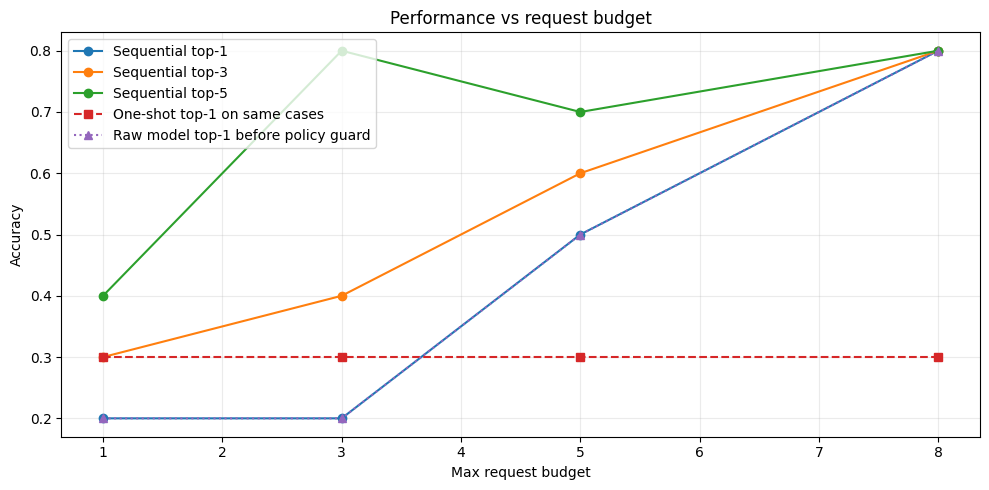

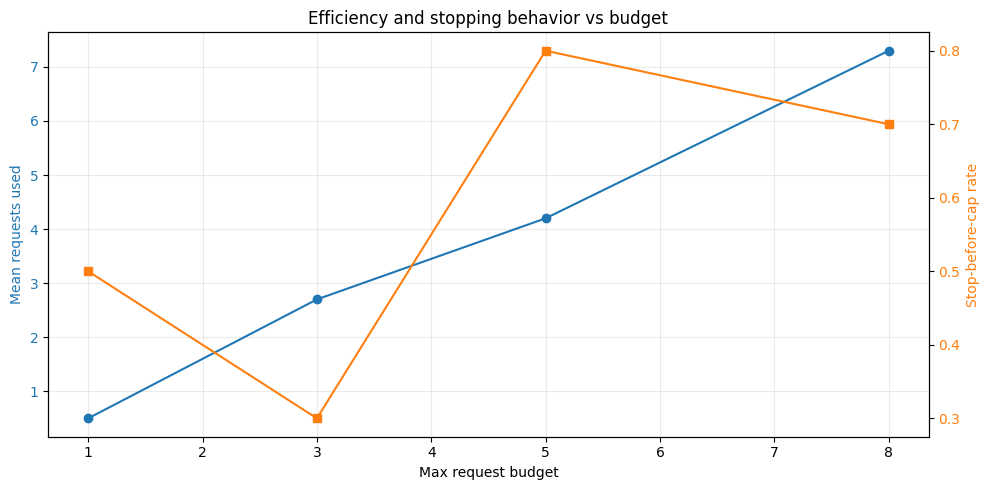

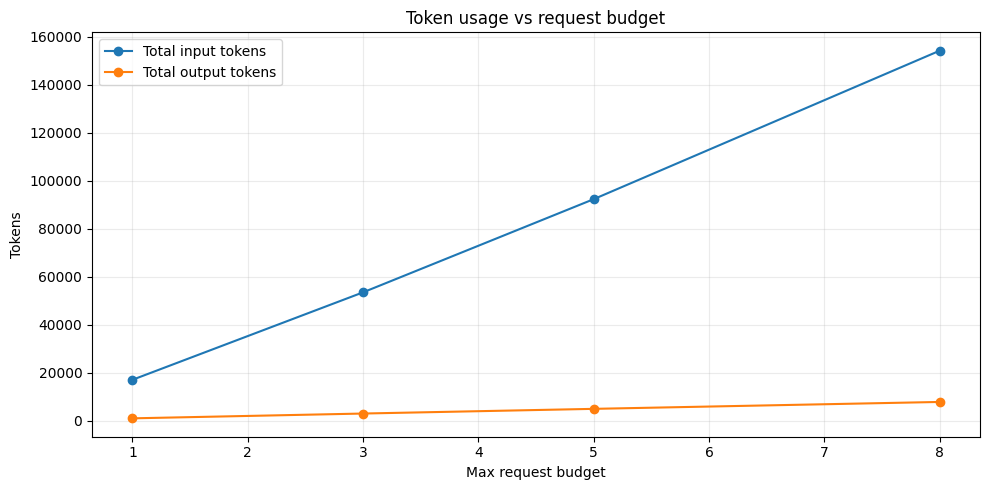

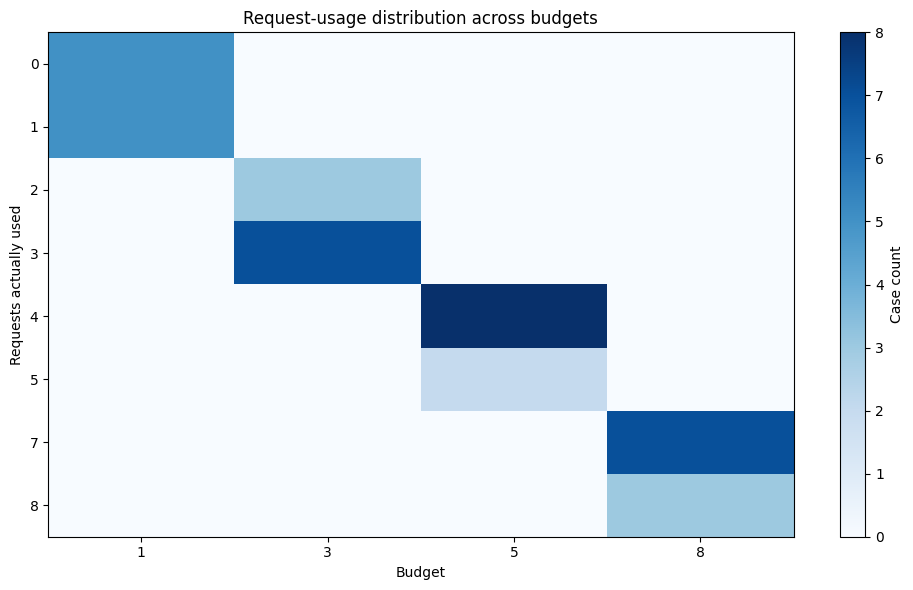

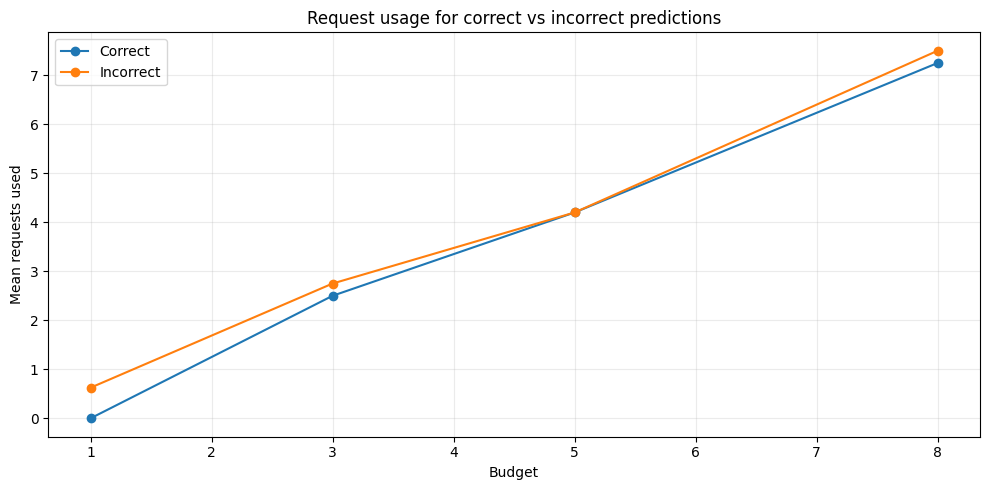

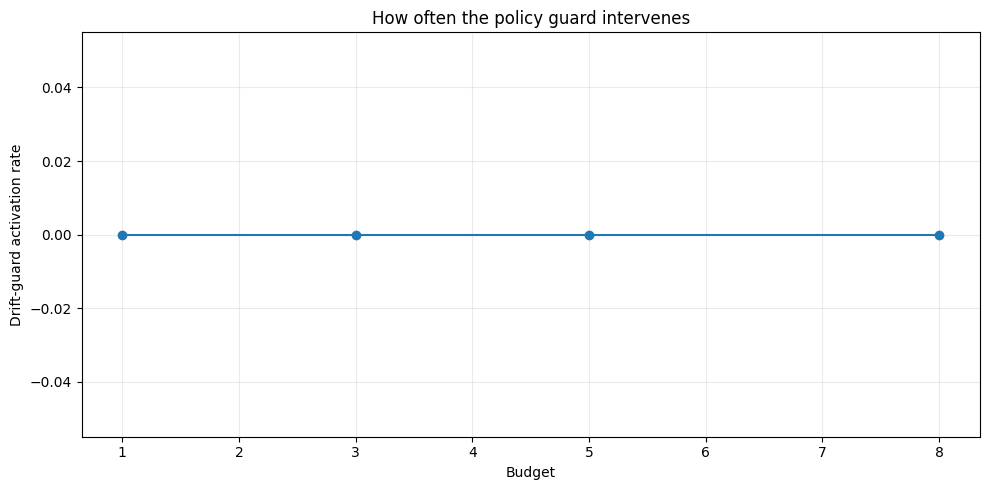

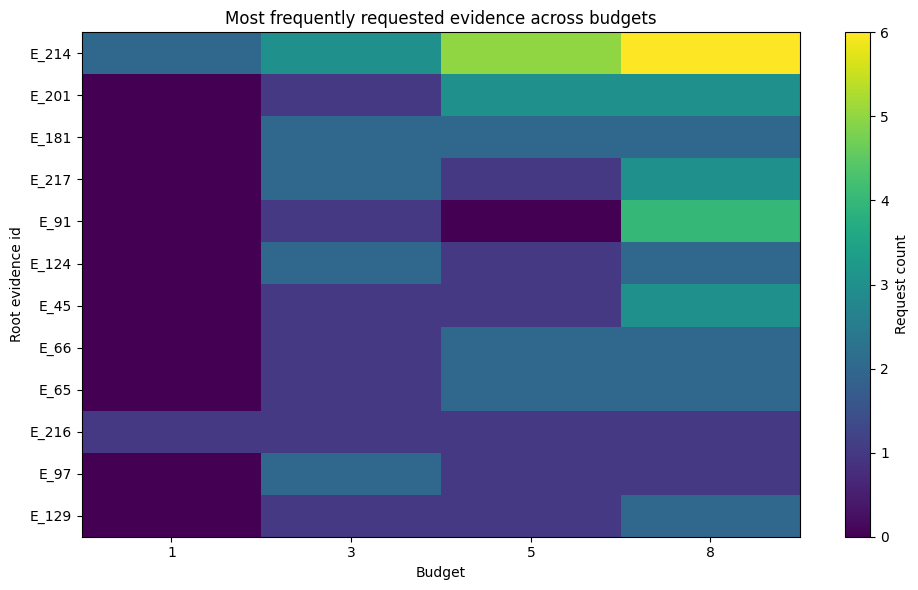

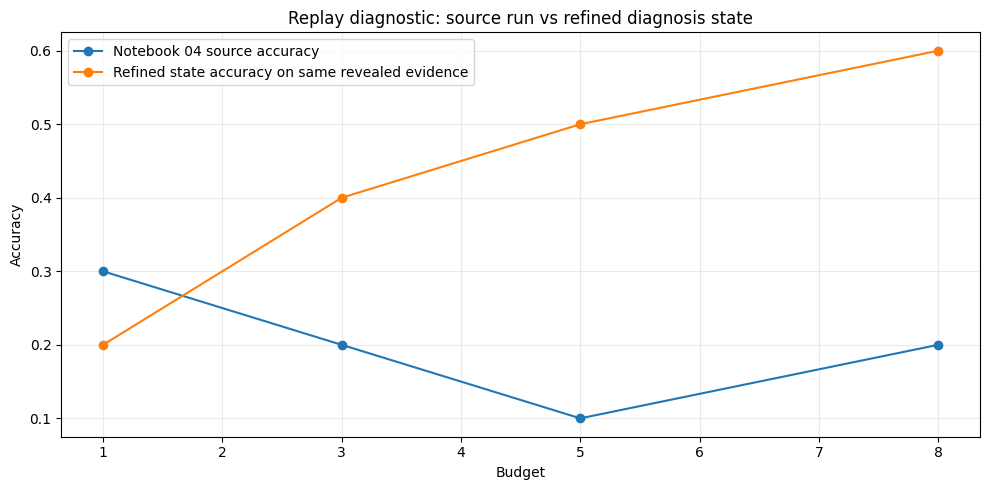

,budget,num_cases,source_accuracy,refined_state_accuracy,mean_refined_margin,accuracy_gain
0,1,10,0.3,0.2,1.046282,-0.1
1,3,10,0.2,0.4,1.213722,0.2
2,5,10,0.1,0.5,1.679326,0.4
3,8,10,0.2,0.6,1.756238,0.4


,budget,num_cases,runtime_seconds,accuracy,top3_accuracy,top5_accuracy,macro_f1,mean_requests,stop_before_cap_rate,mean_api_calls,...,mean_deterministic_margin,drift_override_rate,turn_distribution,one_shot_accuracy_same_cases,one_shot_top3_same_cases,one_shot_top5_same_cases,seq_only_wins,one_shot_only_wins,both_correct,both_wrong
0,1,10,0.004598,0.2,0.3,0.4,0.142857,0.5,0.5,1.0,...,0.969025,0.0,"{'0': 5, '1': 5}",0.3,0.4,0.4,0,1,2,7
1,3,10,0.004411,0.2,0.4,0.8,0.117647,2.7,0.3,3.0,...,1.207318,0.0,"{'2': 3, '3': 7}",0.3,0.4,0.4,0,1,2,7
2,5,10,0.004759,0.5,0.6,0.7,0.357143,4.2,0.8,5.0,...,1.819244,0.0,"{'4': 8, '5': 2}",0.3,0.4,0.4,2,0,3,5
3,8,10,0.004910,0.8,0.8,0.8,0.666667,7.3,0.7,8.0,...,2.970120,0.0,"{'7': 7, '8': 3}",0.3,0.4,0.4,5,0,3,2


In [31]:
summary_path = ARTIFACT_ROOT / "budget_sweep_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("No budget_sweep_summary.csv found. Run the budget sweep cell first.")
summary_frame = pd.read_csv(summary_path)

all_predictions = []
request_counter_by_budget = defaultdict(Counter)
for budget in REQUEST_BUDGETS:
    budget_dir = ARTIFACT_ROOT / f"budget_{budget:03d}"
    pred_path = budget_dir / "predictions.csv"
    trace_path = budget_dir / "traces.jsonl"
    if pred_path.exists():
        pred_frame = pd.read_csv(pred_path)
        pred_frame["budget"] = budget
        all_predictions.append(pred_frame)
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                for step in row.get("trace", []):
                    response = step.get("policy_response") or step.get("agent_response") or {}
                    requested = response.get("requested_evidence_id")
                    if requested:
                        request_counter_by_budget[budget][requested] += 1
all_predictions = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()

plt.figure(figsize=(10, 5))
plt.plot(summary_frame["budget"], summary_frame["accuracy"], marker="o", label="Sequential top-1")
plt.plot(summary_frame["budget"], summary_frame["top3_accuracy"], marker="o", label="Sequential top-3")
plt.plot(summary_frame["budget"], summary_frame["top5_accuracy"], marker="o", label="Sequential top-5")
if "one_shot_accuracy_same_cases" in summary_frame.columns:
    plt.plot(summary_frame["budget"], summary_frame["one_shot_accuracy_same_cases"], linestyle="--", marker="s", label="One-shot top-1 on same cases")
if not all_predictions.empty and "raw_correct" in all_predictions.columns:
    raw_accuracy = all_predictions.groupby("budget")["raw_correct"].mean().reset_index(name="raw_accuracy")
    plt.plot(raw_accuracy["budget"], raw_accuracy["raw_accuracy"], linestyle=":", marker="^", label="Raw model top-1 before policy guard")
plt.xlabel("Max request budget")
plt.ylabel("Accuracy")
plt.title("Performance vs request budget")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "performance_vs_budget.png", dpi=180)
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(summary_frame["budget"], summary_frame["mean_requests"], marker="o", color="tab:blue", label="Mean requests used")
ax1.set_xlabel("Max request budget")
ax1.set_ylabel("Mean requests used", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(summary_frame["budget"], summary_frame["stop_before_cap_rate"], marker="s", color="tab:orange", label="Stop-before-cap rate")
ax2.set_ylabel("Stop-before-cap rate", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
plt.title("Efficiency and stopping behavior vs budget")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "efficiency_and_stopping_vs_budget.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(summary_frame["budget"], summary_frame["total_input_tokens"], marker="o", label="Total input tokens")
plt.plot(summary_frame["budget"], summary_frame["total_output_tokens"], marker="o", label="Total output tokens")
plt.xlabel("Max request budget")
plt.ylabel("Tokens")
plt.title("Token usage vs request budget")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "token_usage_vs_budget.png", dpi=180)
plt.show()

if not all_predictions.empty:
    pivot = all_predictions.pivot_table(
        index="num_requests",
        columns="budget",
        values="case_id",
        aggfunc="count",
        fill_value=0,
    )
    plt.figure(figsize=(10, 6))
    plt.imshow(pivot.values, aspect="auto", cmap="Blues")
    plt.colorbar(label="Case count")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.xlabel("Budget")
    plt.ylabel("Requests actually used")
    plt.title("Request-usage distribution across budgets")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "request_usage_heatmap.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10, 5))
    correct_means = all_predictions.groupby(["budget", "correct"])["num_requests"].mean().unstack(fill_value=0)
    for is_correct, label in [(True, "Correct"), (False, "Incorrect")]:
        if is_correct in correct_means.columns:
            plt.plot(correct_means.index, correct_means[is_correct], marker="o", label=label)
    plt.xlabel("Budget")
    plt.ylabel("Mean requests used")
    plt.title("Request usage for correct vs incorrect predictions")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "requests_correct_vs_incorrect.png", dpi=180)
    plt.show()

    if "drift_guard_triggered" in all_predictions.columns:
        guard_rates = all_predictions.groupby("budget")["drift_guard_triggered"].mean().reset_index()
        plt.figure(figsize=(10, 5))
        plt.plot(guard_rates["budget"], guard_rates["drift_guard_triggered"], marker="o")
        plt.xlabel("Budget")
        plt.ylabel("Drift-guard activation rate")
        plt.title("How often the policy guard intervenes")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "drift_guard_rate_vs_budget.png", dpi=180)
        plt.show()

if request_counter_by_budget:
    all_roots = Counter()
    for counter in request_counter_by_budget.values():
        all_roots.update(counter)
    top_roots = [root for root, _ in all_roots.most_common(12)]
    heatmap = np.zeros((len(top_roots), len(REQUEST_BUDGETS)), dtype=int)
    for col, budget in enumerate(REQUEST_BUDGETS):
        for row, root_id in enumerate(top_roots):
            heatmap[row, col] = request_counter_by_budget[budget].get(root_id, 0)
    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap, aspect="auto", cmap="viridis")
    plt.colorbar(label="Request count")
    plt.yticks(range(len(top_roots)), top_roots)
    plt.xticks(range(len(REQUEST_BUDGETS)), REQUEST_BUDGETS)
    plt.xlabel("Budget")
    plt.ylabel("Root evidence id")
    plt.title("Most frequently requested evidence across budgets")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "top_requested_evidence_heatmap.png", dpi=180)
    plt.show()

replay_summary_path = ARTIFACT_ROOT / "replay_source_run_summary.csv"
if replay_summary_path.exists():
    replay_summary = pd.read_csv(replay_summary_path)
    plt.figure(figsize=(10, 5))
    plt.plot(replay_summary["budget"], replay_summary["source_accuracy"], marker="o", label="Notebook 04 source accuracy")
    plt.plot(replay_summary["budget"], replay_summary["refined_state_accuracy"], marker="o", label="Refined state accuracy on same revealed evidence")
    plt.xlabel("Budget")
    plt.ylabel("Accuracy")
    plt.title("Replay diagnostic: source run vs refined diagnosis state")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "replay_source_vs_refined_accuracy.png", dpi=180)
    plt.show()
    display(replay_summary)

display(summary_frame)


## Qualitative Trace Snapshots

The saved traces now include raw model responses, policy-adjusted responses, deterministic state summaries, and policy-flag interventions.

In [32]:

if summary_frame.empty:
    print("No summary rows available.")
else:
    best_budget = int(summary_frame.sort_values(["accuracy", "top3_accuracy", "budget"], ascending=[False, False, True]).iloc[0]["budget"])
    best_budget_dir = ARTIFACT_ROOT / f"budget_{best_budget:03d}"
    paired_path = best_budget_dir / "paired_vs_one_shot.csv"
    trace_path = best_budget_dir / "traces.jsonl"

    trace_lookup = {}
    if trace_path.exists():
        with trace_path.open("r", encoding="utf-8") as handle:
            for line in handle:
                row = json.loads(line)
                trace_lookup[row["case_id"]] = row

    qualitative_examples = []
    if paired_path.exists():
        paired = pd.read_csv(paired_path)
        candidate_groups = [
            (paired[(paired["correct_seq"]) & (~paired["correct_one_shot"])], "sequential_only_win"),
            (paired[(~paired["correct_seq"]) & (paired["correct_one_shot"])], "one_shot_only_win"),
            (paired[(paired["correct_seq"]) & (paired["correct_one_shot"])], "both_correct"),
        ]
        for group_frame, label in candidate_groups:
            if len(group_frame) == 0:
                continue
            row = group_frame.iloc[0]
            trace_row = trace_lookup.get(str(row["case_id"]))
            qualitative_examples.append(
                {
                    "label": label,
                    "case_id": str(row["case_id"]),
                    "true_pathology": str(row["true_pathology"]),
                    "sequential_prediction": str(row["predicted_pathology"]),
                    "one_shot_prediction": str(row.get("pred_pathology_one_shot", "")),
                    "num_requests": int(row["num_requests"]),
                    "stop_reason": str(row["stop_reason"]),
                    "trace": trace_row,
                }
            )
    with (ARTIFACT_ROOT / "qualitative_examples_best_budget.json").open("w", encoding="utf-8") as handle:
        json.dump(qualitative_examples, handle, indent=2)

    print("Best budget:", best_budget)
    print("Saved qualitative examples to:", ARTIFACT_ROOT / "qualitative_examples_best_budget.json")
    display(pd.DataFrame([{k: v for k, v in item.items() if k != "trace"} for item in qualitative_examples]))


Best budget: 8
Saved qualitative examples to: /Users/bilalawan/claw/assignments/baseline_model/artifacts/sequential_single_agent_refined/single_agent_refined_live_test_1perclass_4budgets_anchor_guard_v1/qualitative_examples_best_budget.json


,label,case_id,true_pathology,sequential_prediction,one_shot_prediction,num_requests,stop_reason
0,sequential_only_win,test:51421,Chagas,Chagas,URTI,8,max_requests_reached
1,both_correct,test:104857,Acute dystonic reactions,Acute dystonic reactions,Acute dystonic reactions,7,agent_stop
